# EDA - Decadimento delle specie

Notebook ordinato in due parti: prima trasformazioni dei dati, poi grafici temporali.

Domanda guida: anche senza il meteorite i dinosauri non aviani si sarebbero estinti in breve, oppure sarebbero ancora vivi adesso?

## Parte 1 - Trasformazioni dei dati

In questa prima parte preparo tutte le tabelle che servono: caricamento, filtri, feature temporali, aggregazioni e discretizzazioni.

### 1. Import librerie

Uso solo librerie base per EDA: Pandas per i dati e Matplotlib per i grafici.

In [1]:
# Importo pandas per lavorare con tabelle e matplotlib per creare grafici.
import pandas as pd
import matplotlib.pyplot as plt

# Definisco due colori da riutilizzare nei grafici.
rosso = "firebrick"
blu = "steelblue"

pd.set_option("display.max_columns", 50)

### 2. Caricamento dataset

Parto dal dataset gia pulito e unito. Nel file origine_dataset uguale a 0 indica i dinosauri, mentre origine_dataset uguale a 1 indica le piante.

In [2]:
# Carico il dataset pulito gia presente nella cartella.
df = pd.read_csv("dataset_fossili_pulito.csv")

# Controllo dimensione del dataset e prime righe.
print("Righe e colonne:", df.shape)
df.head()

Righe e colonne: (80011, 24)


,id,nome,rango,intervallo_iniziale,intervallo_finale,eta_massima,eta_minima,longitudine,latitudine,codice_paese,stato_regione,formazione,gruppo_geologico,phylum,classe,ordine,famiglia,genere,origine_dataset,fonte_phylum,fonte_classe,fonte_ordine,fonte_famiglia,fonte_genere
0,130209,Chaoyangsaurus youngi,species,Late Kimmeridgian,Valanginian,152.21,132.60,123.966698,42.933300,CN,Liaoning,Tuchengzi,NaN,Chordata,Ornithischia,NaN,Chaoyangsauridae,Chaoyangsaurus,0,originale,originale,NaN,originale,originale
1,130294,Protarchaeopteryx robusta,species,Late Barremian,Early Aptian,125.77,119.57,120.733330,41.799999,CN,Liaoning,Yixian,Jehol,Chordata,Reptilia,NaN,Archaeopterygidae,Protarchaeopteryx,0,originale,originale,NaN,dinosaurs.csv_family,originale
2,130295,Caudipteryx zoui,species,Late Barremian,Early Aptian,125.77,119.57,120.733330,41.799999,CN,Liaoning,Yixian,Jehol,Chordata,Reptilia,NaN,Caudipterygidae,Caudipteryx,0,originale,originale,NaN,data.csv_taxonomy,originale
3,137486,Theropoda,unranked clade,Middle Campanian,Late Campanian,83.60,72.20,99.599998,43.299999,MN,Omnogov,Baruungoyot,NaN,Chordata,Reptilia,NaN,NaN,NaN,0,originale,originale,NaN,NaN,NaN
4,138867,Dinosauria,unranked clade,Berriasian,Aptian,143.10,113.20,34.726665,30.538889,IL,Negev,Hatira,NaN,Chordata,Reptilia,NaN,NaN,NaN,0,originale,originale,NaN,NaN,NaN


### 3. Selezione delle colonne utili

Tengo solo le colonne che servono alla domanda, come esempio di selezione delle feature.

In [3]:
# Tengo solo le colonne utili per questa analisi.
colonne_utili = [
    "id", "nome", "rango", "eta_massima", "eta_minima",
    "classe", "ordine", "famiglia", "genere", "origine_dataset"
]

# Creo una copia ridotta del dataframe.
df = df[colonne_utili].copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80011 entries, 0 to 80010
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               80011 non-null  int64  
 1   nome             80011 non-null  str    
 2   rango            80011 non-null  str    
 3   eta_massima      80011 non-null  float64
 4   eta_minima       80011 non-null  float64
 5   classe           57989 non-null  str    
 6   ordine           33702 non-null  str    
 7   famiglia         38541 non-null  str    
 8   genere           65293 non-null  str    
 9   origine_dataset  80011 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 6.1 MB


### 4. Pulizia preliminare

Creo una colonna testuale per origine del record e controllo le eta.

In [4]:
# Converto le eta in numeri; eventuali valori non validi diventano NaN.
df["eta_massima"] = pd.to_numeric(df["eta_massima"], errors="coerce")
df["eta_minima"] = pd.to_numeric(df["eta_minima"], errors="coerce")

# Rendo piu leggibile la colonna che distingue dinosauri e piante.
df["origine"] = df["origine_dataset"].replace({0: "dinosauri", 1: "piante"})

# Guardo le statistiche base delle colonne temporali.
df[["eta_massima", "eta_minima"]].describe()

,eta_massima,eta_minima
count,80011.000000,80011.000000
mean,139.241432,126.532028
std,55.941109,54.276596
min,0.011700,0.000000
25%,89.800000,72.200000
50%,125.770000,113.200000
75%,174.700000,168.200000
max,298.900000,250.500000


### 5. Filtro sui dinosauri non aviani

Tengo solo dinosauri non aviani prima o al limite K-Pg, evitando record post-K-Pg.

In [5]:
# Filtro solo i dinosauri non aviani presenti prima o al limite K-Pg.
dino = df[
    (df["origine"] == "dinosauri")
    & (df["classe"].fillna("") != "Aves")
    & (df["eta_massima"] >= 66)
].copy()

# Creo un sottoinsieme con solo i record classificati a livello specie.
dino_specie = dino[
    (dino["rango"] == "species")
    & (dino["nome"].notna())
].copy()

# Riassumo quanti record, specie e generi rimangono dopo i filtri.
riepilogo = pd.DataFrame({
    "metrica": [
        "record dinosauri non aviani pre-K-Pg",
        "record a livello specie",
        "specie uniche",
        "generi unici"
    ],
    "valore": [
        len(dino),
        len(dino_specie),
        dino_specie["nome"].nunique(),
        dino["genere"].nunique()
    ]
})

riepilogo

,metrica,valore
0,record dinosauri non aviani pre-K-Pg,21673
1,record a livello specie,6069
2,specie uniche,2110
3,generi unici,1688


### 6. Feature temporali semplici

Creo eta_media_ma e range_temporale_ma, due feature utili per lavorare sul tempo.

In [6]:
# Eta media: punto centrale dell'intervallo temporale del fossile.
dino_specie["eta_media_ma"] = (dino_specie["eta_massima"] + dino_specie["eta_minima"]) / 2

# Range temporale: quanto e' ampio l'intervallo di datazione.
dino_specie["range_temporale_ma"] = dino_specie["eta_massima"] - dino_specie["eta_minima"]

dino_specie[["eta_media_ma", "range_temporale_ma"]].describe()

,eta_media_ma,range_temporale_ma
count,6069.000000,6069.000000
mean,116.252958,9.578095
std,49.646894,6.333478
min,63.830000,0.400000
25%,77.900000,6.200000
50%,97.200000,8.200000
75%,148.950000,11.400000
max,249.301000,167.280000


### 7. Discretizzazione in fasce temporali

Divido il Cretaceo superiore in fasce da circa 5 milioni di anni e conto specie e generi.

In [7]:
# Definisco fasce temporali dal passato piu lontano verso il limite K-Pg.
fasce = [
    (96, 100.5),
    (91, 96),
    (86, 91),
    (81, 86),
    (76, 81),
    (71, 76),
    (66, 71)
]

# In questa lista salvo i risultati calcolati per ogni fascia.
righe = []

# Per ogni fascia conto quanti record, specie e generi sono presenti.
for giovane, antico in fasce:
    # Tengo i fossili il cui intervallo temporale si sovrappone alla fascia.
    dati_fascia = dino[
        (dino["eta_massima"] >= giovane)
        & (dino["eta_minima"] <= antico)
    ]

    # Per le specie uso solo i record classificati come species.
    dati_fascia_specie = dati_fascia[dati_fascia["rango"] == "species"]

    righe.append({
        "fascia_ma": f"{antico}-{giovane}",
        "specie_uniche": dati_fascia_specie["nome"].nunique(),
        "generi_unici": dati_fascia["genere"].nunique(),
        "record": len(dati_fascia)
    })

# Trasformo la lista di risultati in una tabella.
tab_decadimento = pd.DataFrame(righe)
tab_decadimento

,fascia_ma,specie_uniche,generi_unici,record
0,100.5-96,308,297,2774
1,96-91,260,260,2001
2,91-86,210,201,1183
3,86-81,542,479,5766
4,81-76,442,394,4964
5,76-71,697,590,9034
6,71-66,395,357,4923


### 8. Aggregazione: ultima occorrenza osservata

Con groupby raggruppo i record per specie e calcolo prima comparsa, ultima occorrenza osservata e numero di record.

In [8]:
# Raggruppo per specie per ottenere un riepilogo per ogni nome scientifico.
range_specie = dino_specie.groupby("nome").agg({
    "eta_massima": "max",
    "eta_minima": "min",
    "id": "count"
}).reset_index()

# Rinomino le colonne per renderle piu chiare.
range_specie = range_specie.rename(columns={
    "eta_massima": "prima_comparsa_ma",
    "eta_minima": "ultima_occ_ma",
    "id": "numero_record"
})

range_specie.head()

,nome,prima_comparsa_ma,ultima_occ_ma,numero_record
0,Aardonyx celestae,201.4,192.9,1
1,Abavornis bonaparti,93.9,89.8,1
2,Abdarainurus barsboldi,85.7,72.2,1
3,Abditosaurus kuehnei,72.2,66.0,2
4,Abelichnus astigarrae,100.5,93.9,2


### 9. Discretizzazione ultima occorrenza

Uso pd.cut per trasformare ultima occorrenza osservata in classi temporali.

In [9]:
# Definisco le fasce temporali per classificare l'ultima occorrenza osservata.
bins = [66, 71, 76, 81, 86, 91, 96, 100.5, 145, 252]
labels = ["66-71", "71-76", "76-81", "81-86", "86-91", "91-96", "96-100.5", "100.5-145", "145-252"]

# Assegno ogni specie a una fascia in base alla sua ultima occorrenza osservata.
range_specie["fascia_ultima_occ"] = pd.cut(
    range_specie["ultima_occ_ma"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Conto quante specie hanno l'ultima occorrenza in ogni fascia.
ultime_occ = range_specie["fascia_ultima_occ"].value_counts(sort=False).reset_index()
ultime_occ.columns = ["fascia_ultima_occ", "numero_specie"]

# Riordino le fasce: a sinistra le eta piu antiche, a destra quelle piu vicine a noi.
ultime_occ = ultime_occ.iloc[::-1].reset_index(drop=True)

ultime_occ

,fascia_ultima_occ,numero_specie
0,145-252,549
1,100.5-145,595
2,96-100.5,0
3,91-96,87
4,86-91,83
5,81-86,98
6,76-81,0
7,71-76,303
8,66-71,394


## Parte 2 - Grafici

Da qui in poi uso le tabelle gia create per costruire i grafici temporali.

### Grafico 1 - Distribuzione temporale

Istogramma delle eta medie dei record a livello specie.

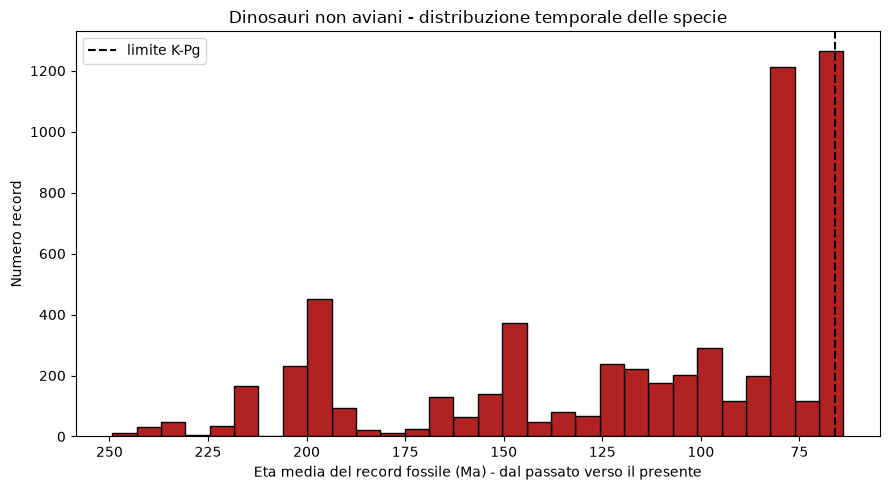

In [10]:
# Disegno un istogramma per vedere dove si concentrano i record nel tempo.
plt.figure(figsize=(9, 5))
plt.hist(dino_specie["eta_media_ma"].dropna(), bins=30, color=rosso, edgecolor="black")

# Segno il limite K-Pg, cioe circa 66 milioni di anni fa.
plt.axvline(66, color="black", linestyle="--", label="limite K-Pg")

# Inverto l'asse x: a sinistra il passato piu lontano, a destra il presente.
plt.gca().invert_xaxis()
plt.title("Dinosauri non aviani - distribuzione temporale delle specie")
plt.xlabel("Eta media del record fossile (Ma) - dal passato verso il presente")
plt.ylabel("Numero record")
plt.legend()
plt.tight_layout()
plt.show()

### Grafico 2 - Specie e generi nelle fasce temporali

Line plot dei taxa osservati, ordinato dal passato piu lontano verso il limite K-Pg.

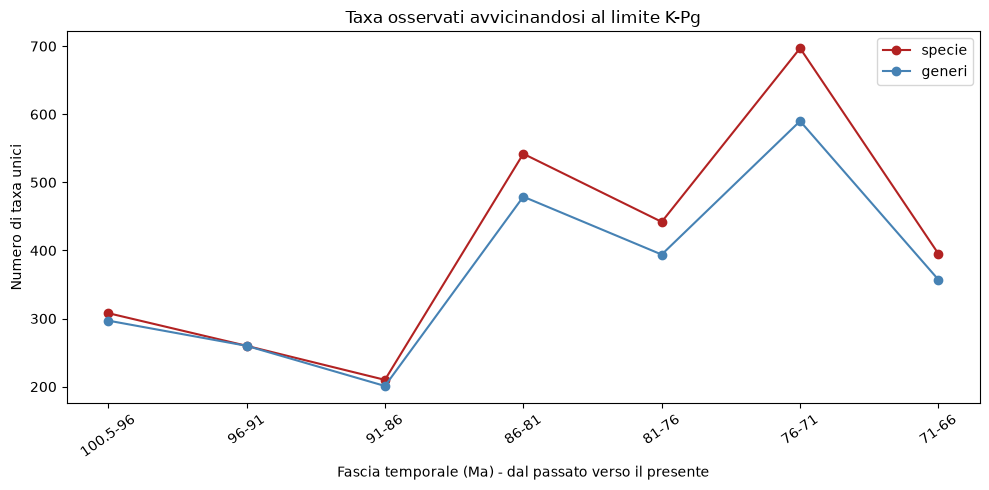

In [11]:
# Grafico l'andamento di specie e generi nelle fasce temporali.
plt.figure(figsize=(10, 5))
plt.plot(tab_decadimento["fascia_ma"], tab_decadimento["specie_uniche"], marker="o", color=rosso, label="specie")
plt.plot(tab_decadimento["fascia_ma"], tab_decadimento["generi_unici"], marker="o", color=blu, label="generi")
plt.title("Taxa osservati avvicinandosi al limite K-Pg")
plt.xlabel("Fascia temporale (Ma) - dal passato verso il presente")
plt.ylabel("Numero di taxa unici")
plt.xticks(rotation=35)
plt.legend()
plt.tight_layout()
plt.show()

### Grafico 3 - Ultima occorrenza osservata

Grafico a barre delle fasce in cui compare ultima occorrenza osservata delle specie.

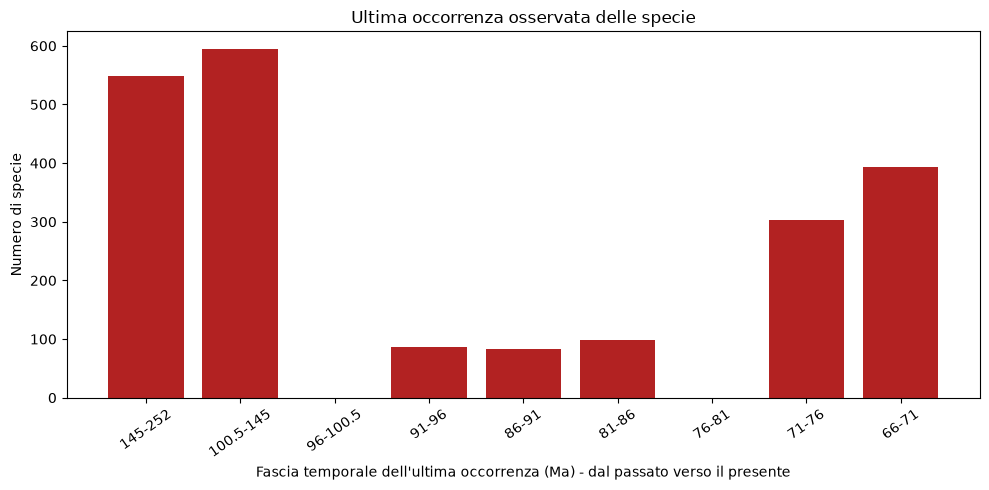

In [12]:
# Grafico il numero di specie per fascia dell'ultima occorrenza.
plt.figure(figsize=(10, 5))
plt.bar(ultime_occ["fascia_ultima_occ"], ultime_occ["numero_specie"], color=rosso)
plt.title("Ultima occorrenza osservata delle specie")
plt.xlabel("Fascia temporale dell'ultima occorrenza (Ma) - dal passato verso il presente")
plt.ylabel("Numero di specie")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

## Conclusione

Dalla tabella delle fasce temporali non si vede un decadimento regolare fino a zero prima del limite K-Pg. Anche nella fascia piu vicina al meteorite, 71-66 Ma, sono ancora osservate molte specie e molti generi.

Quindi, con questi dati, la risposta piu prudente e': **non abbiamo evidenza sufficiente per dire che i dinosauri non aviani si sarebbero estinti in breve anche senza meteorite**.

Pero non possiamo nemmeno dire che sarebbero ancora vivi oggi. Questa EDA guarda solo il record fossile disponibile e non simula il futuro, il clima, il vulcanismo, la competizione o altri eventi.

Frase utile per il report:

> Nel dataset analizzato i dinosauri non aviani non mostrano un decadimento tale da far prevedere una scomparsa naturale imminente prima del limite K-Pg. L'ipotesi di una estinzione a breve termine anche senza meteorite non e' quindi supportata da questa EDA, anche se il record fossile non permette di stabilire se sarebbero sopravvissuti fino a oggi.